<a href="https://colab.research.google.com/github/hassanansari00/home_advantage_football_reasearch/blob/main/home_vs_away_team_analysis1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd

df = pd.read_excel('PL 2023-24.csv.xlsx')

columns_we_need=[
    'Date','FTHG','FTAG',
    'FTR','HS', 'AS','HST','AST','HF',
    'AF','HY','AY'
]

clean_df = df[columns_we_need].copy()

clean_df = clean_df.rename(columns={
    'FTHG': 'Home_Goals',
    'FTAG': 'Away_Goals',
    'FTR':  'Match_Result',
    'HS':   'Home_Shots',
    'AS':   'Away_Shots',
    'HST':  'Home_Shots_Target',
    'AST':  'Away_Shots_Target',
    'HF':   'Home_Fouls',
    'AF':   'Away_Fouls',
    'HY':   'Home_Yellows',
    'AY':   'Away_Yellows'
})
clean_df.head()

# Calculate win rates and draw rates
total_matches = len(clean_df)
home_wins = len(clean_df[clean_df['Match_Result'] == 'H'])
away_wins = len(clean_df[clean_df['Match_Result'] == 'A'])
draws = len(clean_df[clean_df['Match_Result'] == 'D'])

home_win_rate = (home_wins / total_matches) * 100
away_win_rate = (away_wins / total_matches) * 100
draw_rate = (draws / total_matches) * 100

print(f"\nHome Win Rate: {home_win_rate:.2f}%")
print(f"Away Win Rate: {away_win_rate:.2f}%")
print(f"Draw Rate: {draw_rate:.2f}%")


Home Win Rate: 46.05%
Away Win Rate: 32.37%
Draw Rate: 21.58%


--- QUICK INSIGHTS ---
Goals per match:  Home = 1.80 | Away = 1.48
Shots on target:  Home = 5.44 | Away = 4.43
Yellow cards:     Home = 1.91 | Away = 2.26
Home win rate: 46.05%
Away win rate: 32.37%
Draw rate: 21.58%


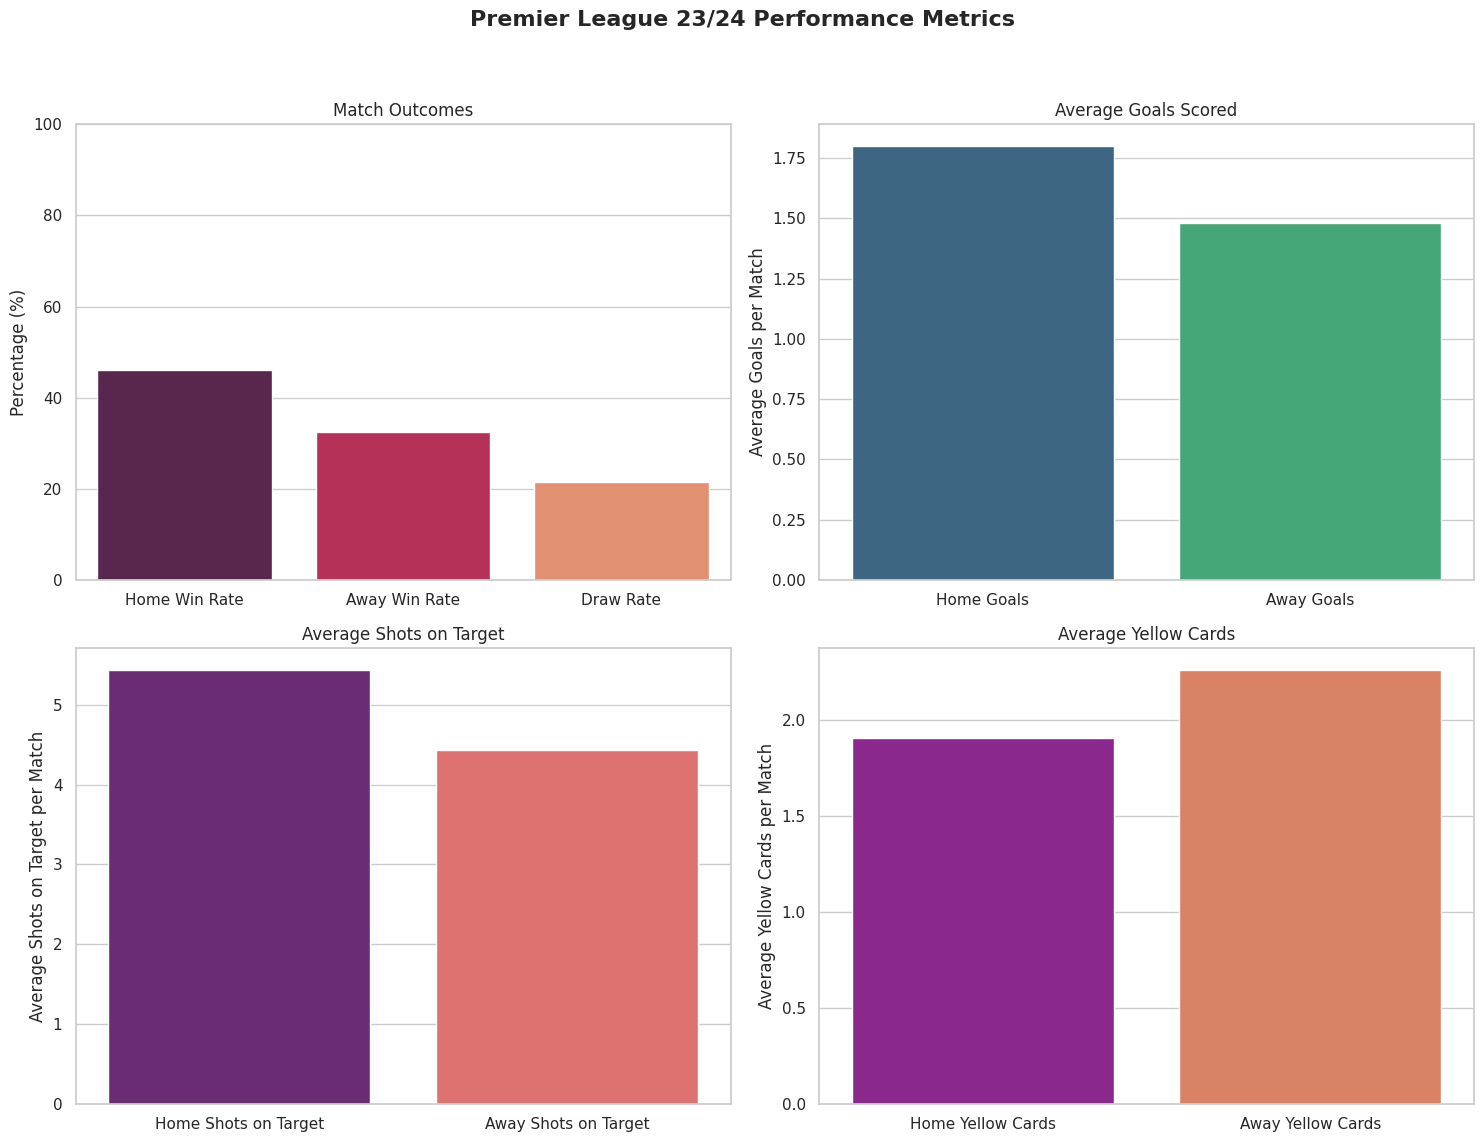

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. THE MATH: Calculating the Averages ---
# We use the .mean() function to find the average per match over the whole season
home_goals_avg = clean_df['Home_Goals'].mean()
away_goals_avg = clean_df['Away_Goals'].mean()

home_shots_avg = clean_df['Home_Shots_Target'].mean()
away_shots_avg = clean_df['Away_Shots_Target'].mean()

home_yellows_avg = clean_df['Home_Yellows'].mean()
away_yellows_avg = clean_df['Away_Yellows'].mean()

# home_win_rate, away_win_rate, and draw_rate are already calculated in clean_df cell

# Print the results so we can see the exact numbers
print("--- QUICK INSIGHTS ---")
print(f"Goals per match:  Home = {home_goals_avg:.2f} | Away = {away_goals_avg:.2f}")
print(f"Shots on target:  Home = {home_shots_avg:.2f} | Away = {away_shots_avg:.2f}")
print(f"Yellow cards:     Home = {home_yellows_avg:.2f} | Away = {away_yellows_avg:.2f}")
print(f"Home win rate: {home_win_rate:.2f}%")
print(f"Away win rate: {away_win_rate:.2f}%")
print(f"Draw rate: {draw_rate:.2f}%")

sns.set_theme(style="whitegrid") # Makes the chart look modern and clean

# --- 2. THE VISUALS: Creating a Single Figure with Subplots ---

fig, axes = plt.subplots(2, 2, figsize=(15, 12)) # 2 rows, 2 columns for 4 charts
fig.suptitle('Premier League 23/24 Performance Metrics', fontsize=16, fontweight='bold')

# Chart 1: Win Rates (NOW FIRST) - Including Draw Rate
win_metrics = ['Home Win Rate', 'Away Win Rate', 'Draw Rate']
win_averages = [home_win_rate, away_win_rate, draw_rate]
sns.barplot(x=win_metrics, y=win_averages, palette='rocket', hue=win_metrics, legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Match Outcomes')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].set_ylim(0, 100) # Set y-axis limit for percentage

# Chart 2: Average Goals (MOVED TO SECOND POSITION)
goal_metrics = ['Home Goals', 'Away Goals']
goal_averages = [home_goals_avg, away_goals_avg]
sns.barplot(x=goal_metrics, y=goal_averages, palette='viridis', hue=goal_metrics, legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Average Goals Scored')
axes[0, 1].set_ylabel('Average Goals per Match')

# Chart 3: Average Shots on Target (MOVED TO THIRD POSITION)
shots_metrics = ['Home Shots on Target', 'Away Shots on Target']
shots_averages = [home_shots_avg, away_shots_avg]
sns.barplot(x=shots_metrics, y=shots_averages, palette='magma', hue=shots_metrics, legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Average Shots on Target')
axes[1, 0].set_ylabel('Average Shots on Target per Match')

# Chart 4: Average Yellow Cards (MOVED TO FOURTH POSITION)
yellows_metrics = ['Home Yellow Cards', 'Away Yellow Cards']
yellows_averages = [home_yellows_avg, away_yellows_avg]
sns.barplot(x=yellows_metrics, y=yellows_averages, palette='plasma', hue=yellows_metrics, legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Average Yellow Cards')
axes[1, 1].set_ylabel('Average Yellow Cards per Match')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap, leaving space for suptitle
plt.show()

In [17]:
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,2023-08-11,20:00:00,Burnley,Man City,0,3,A,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,2023-08-12,12:30:00,Arsenal,Nott'm Forest,2,1,H,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,2023-08-12,15:00:00,Bournemouth,West Ham,1,1,D,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,2023-08-12,15:00:00,Brighton,Luton,4,1,H,1,0,...,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,2023-08-12,15:00:00,Everton,Fulham,0,1,A,0,0,...,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88
